# QRAM figures

Frequency allocation for a QRAM module: **three transmons coupled by a single SNAIL**,
with one of the transmons also coupled directly to a QRAM register of four states spaced
100 MHz apart around 5 GHz.

`GateFidelityOptimizer` searches qubit/SNAIL frequencies that minimize the
frequency-crowding infidelity of every two-qubit gate. System parameters are the
defaults used for the standard modules in `src/notebooks/07_numerics.ipynb`.

The SNAIL subharmonic $f_\mathrm{SNAIL}/2$ is now a **coherent** spectator, built into
`detuning_fit.compute_infidelity_parameters` with the same simulate-and-fit pattern as
the other spectator families. The incoherent speed-limit route is therefore switched off
(`use_lifetime=False`), which also makes "optimal fidelity without decoherence"
well-posed: the subharmonic is penalized in the coherent cost where the search can see
it.

In [1]:
from pathlib import Path

import lovelyplots  # noqa: F401  (registers matplotlib styles)
import matplotlib.pyplot as plt
import numpy as np
import scienceplots  # noqa: F401  (registers matplotlib styles)

from corral_crowding.allocation_optimizer import GateFidelityOptimizer
from corral_crowding.detuning_fit import decay_fit
from corral_crowding.module_graph import QuantumModuleGraph

FIG_DIR = Path("figs")
FIG_DIR.mkdir(exist_ok=True)

## System parameters

The standard-module defaults from the `GateFidelityOptimizer` cells of
`src/notebooks/07_numerics.ipynb`, with `use_lifetime=False` so the subharmonic is
counted once, coherently.

In [2]:
NUM_QUBITS = 3  # three transmons, all-to-all through one SNAIL

SYSTEM_PARAMS = dict(
    min_bare_space_ghz=0.2,   # 200 MHz minimum spacing between bare modes
    lambdaq=0.08,             # qubit participation in the SNAIL mode
    eta=1.8,                  # pump-induced SNAIL nonlinearity scale
    g3=60e6,                  # three-wave mixing strength, 60 MHz
    qubit_bounds=(3.3, 5.7),  # GHz
    snail_bounds=(4.2, 4.7),  # GHz
    use_lifetime=False,       # subharmonic is coherent now; no speed-limit T_1 term
)
SYSTEM_PARAMS

{'min_bare_space_ghz': 0.2,
 'lambdaq': 0.08,
 'eta': 1.8,
 'g3': 60000000.0,
 'qubit_bounds': (3.3, 5.7),
 'snail_bounds': (4.2, 4.7),
 'use_lifetime': False}

## The QRAM register

Four states spaced 100 MHz apart, centered on 5 GHz.

In [3]:
QRAM_CENTER_GHZ = 5.0
QRAM_SPACING_GHZ = 0.1
QRAM_NUM_STATES = 4


def qram_state_frequencies(
    center=QRAM_CENTER_GHZ, spacing=QRAM_SPACING_GHZ, num=QRAM_NUM_STATES
):
    """`num` equally spaced frequencies (GHz), symmetric about `center`."""
    offsets = (np.arange(num) - (num - 1) / 2) * spacing
    return center + offsets


QRAM_FREQS = qram_state_frequencies()
print(f"QRAM states: {QRAM_FREQS} GHz")

QRAM states: [4.85 4.95 5.05 5.15] GHz


## The SNAIL subharmonic as a coherent spectator

Added to `compute_infidelity_parameters` following the existing pattern exactly:

| | prefactor | spectator operator | Hilbert space |
|---|---|---|---|
| `qubit-qubit` | $6\eta\lambda_q^2 g_3$ | $q_1^\dagger q_3 + \mathrm{h.c.}$ | 3 qubits |
| `snail-qubit` | $6\eta\lambda_q g_3$ | $q_1^\dagger s + \mathrm{h.c.}$ | 2 qubits + SNAIL |
| `qubit-sub` | $3\eta^2\lambda_q g_3$ | $q_3^\dagger + q_3$ | 3 qubits |
| **`snail-sub`** | $3\eta^2 \lambda_\mathrm{sub} g_3$ | $s^\dagger + s$ | 2 qubits + SNAIL |

Same second-order (two-pump-photon) direct-drive structure as `qubit-sub`, but the
driven mode is the **8-level SNAIL** rather than a two-level qubit -- so pumping near
$f_\mathrm{SNAIL}/2$ climbs the SNAIL's ladder, which is the leakage being modelled. It
is simulated by `simulate_infidelity` and fitted by `decay_fit` like every other family.

### One honest caveat on the prefactor

Counting participations the way the other three do -- one factor of $\lambda_q$ per
*qubit* mode in the operator, $1$ for the SNAIL mode -- argues for
$\lambda_\mathrm{sub} = 1$. That is **not** the default, because at $1$ the prefactor is
$3\eta^2 g_3 \approx 583$ MHz, giving $g_s/\Delta \approx 0.6-3.7$ across a
50-1000 MHz sweep: far outside the perturbative regime `simulate_infidelity` assumes.
The simulated infidelity then runs 0.21-0.97 and is *non-monotonic* in detuning, which
the monotonic `decay_fit` power law cannot represent. `curve_fit` still returns
*something* (a meaningless $x_0 \approx 10^{16}$, $x_1 < 0$), so `fit_infidelity` now
checks the residual and raises a `RuntimeWarning` when the ansatz does not fit -- at
$\lambda_\mathrm{sub} = 1$ the residual is 42% of the peak infidelity.

Physically that says the subharmonic is not a perturbative spectator but a hard
exclusion zone -- which is exactly why `speedlimit_fit.py` treated it as a pump-power
ceiling. The default $\lambda_\mathrm{sub} = \lambda_q$ keeps the term perturbative and
fittable; pass `snail_sub_participation=1.0` only alongside a different fitting ansatz.

In [4]:
_probe = GateFidelityOptimizer(QuantumModuleGraph(NUM_QUBITS), **SYSTEM_PARAMS)

print("Coherent spectator infidelity vs detuning from the pump (fitted decay_fit):\n")
_families = ["qubit-qubit", "snail-qubit", "qubit-sub", "snail-sub"]
print(f"{'detuning':>10}" + "".join(f"{f:>14}" for f in _families))
for _d in [50, 100, 200, 400, 800]:
    _row = "".join(
        f"{decay_fit(_d, *_probe.infidelity_params[f]):>14.3e}" for f in _families
    )
    print(f"{_d:>7} MHz" + _row)

print("\nfitted params (x0, x1):")
for _f in _families:
    print(f"  {_f:<12} {np.round(_probe.infidelity_params[_f], 4)}")
print("\nsnail-sub is the stiffest family: ~6x qubit-sub at equal detuning, because the")
print("driven mode is the 8-level SNAIL rather than a two-level qubit. Compare the")
print("incoherent speed-limit term it replaces, which was a nearly flat ~5e-3.")

Coherent spectator infidelity vs detuning from the pump (fitted decay_fit):

  detuning   qubit-qubit   snail-qubit     qubit-sub     snail-sub
     50 MHz     2.511e-04     2.666e-01     7.618e-02     4.708e-01
    100 MHz     6.278e-05     7.260e-02     1.946e-02     1.399e-01
    200 MHz     1.570e-05     1.897e-02     4.917e-03     3.837e-02
    400 MHz     3.924e-06     4.849e-03     1.236e-03     1.006e-02
    800 MHz     9.810e-07     1.226e-03     3.098e-04     2.578e-03

fitted params (x0, x1):
  qubit-qubit  [0.157  0.0044]
  snail-qubit  [198.4177   4.5586]
  qubit-sub    [49.7076  1.0881]
  snail-sub    [422.7186   9.9266]

snail-sub is the stiffest family: ~6x qubit-sub at equal detuning, because the
driven mode is the 8-level SNAIL rather than a two-level qubit. Compare the
incoherent speed-limit term it replaces, which was a nearly flat ~5e-3.


## A QRAM-aware optimizer

One gap remains, unrelated to the subharmonic: `min_bare_space_ghz` is enforced only
among the qubit and SNAIL bare modes, so **nothing stops a transmon from landing on a
QRAM state**. `QramAwareOptimizer` adds the QRAM states to that spacing rule, for the
qubits and for the SNAIL. Nothing else is overridden -- the subharmonic is handled by the
library now.

In [5]:
class QramAwareOptimizer(GateFidelityOptimizer):
    """`GateFidelityOptimizer` that also keeps bare modes clear of the QRAM states.

    The library enforces `min_bare_space_ghz` only among the qubit and SNAIL modes; the
    QRAM register sits inside the qubit tuning range and needs the same clearance.
    """

    def __init__(self, *args, qram_freqs=None, **kwargs):
        super().__init__(*args, **kwargs)
        if qram_freqs is None:
            qram_freqs = qram_state_frequencies()
        self.qram_freqs = np.asarray(qram_freqs, dtype=float)

    def _qram_spacing_cost(self, freq):
        """Penalty for `freq` crowding any QRAM state, same ramp as the library's."""
        cost = 0.0
        for f_qram in self.qram_freqs:
            distance = abs(freq - f_qram)
            if distance < self.min_bare_space_ghz:
                cost += 1.0 - distance / self.min_bare_space_ghz
        return cost

    def _compute_bare_infidelity(self, edge, interaction_data):
        cost = super()._compute_bare_infidelity(edge, interaction_data)
        return cost + self._qram_spacing_cost(
            interaction_data["qubit-resonance"][edge]
        )

    def compute_total_infidelity(self, frequencies):
        # The library's bare-mode loop only walks the qubit modes, so the SNAIL mode
        # needs its own clearance term against the QRAM states.
        return super().compute_total_infidelity(frequencies) + self._qram_spacing_cost(
            frequencies[-1]
        )

## Optimize the three-qubit module

`optimize_frequencies` runs a multi-start Nelder-Mead search (128 random restarts by
default) and keeps the allocation with the lowest mean gate infidelity.

In [6]:
np.random.seed(0)  # reproducible multi-start search

module = QuantumModuleGraph(num_qubits=NUM_QUBITS)
optimizer = QramAwareOptimizer(module, qram_freqs=QRAM_FREQS, **SYSTEM_PARAMS)
opt_frequencies, opt_cost = optimizer.optimize_frequencies()

qubit_freqs, snail_freq = opt_frequencies[:-1], opt_frequencies[-1]
print(f"Qubit frequencies: {np.round(qubit_freqs, 4)} GHz")
print(f"SNAIL frequency:   {snail_freq:.4f} GHz")
print(f"Mean gate infidelity (coherent, no decoherence): {opt_cost:.6e}")

  0%|          | 0/128 [00:00<?, ?it/s]

  6%|▋         | 8/128 [00:00<00:01, 72.37it/s]

 12%|█▎        | 16/128 [00:00<00:01, 62.15it/s]

 19%|█▉        | 24/128 [00:00<00:01, 67.95it/s]

 25%|██▌       | 32/128 [00:00<00:01, 68.38it/s]

...

 82%|████████▏ | 105/128 [00:01<00:00, 71.01it/s]

 88%|████████▊ | 113/128 [00:01<00:00, 68.57it/s]

 95%|█████████▍| 121/128 [00:01<00:00, 70.61it/s]

100%|██████████| 128/128 [00:01<00:00, 69.83it/s]

Optimization terminated successfully.
Qubit frequencies: [3.5004 3.3004 3.8278] GHz
SNAIL frequency:   4.6499 GHz
Mean gate infidelity (coherent, no decoherence): 5.401243e-03


### Per-gate fidelities and a separation audit

Every number here is coherent -- crosstalk and subharmonic leakage, no $T_1$. The audit
shows each gate pump's distance to $f_\mathrm{SNAIL}/2$ next to what the `snail-sub` term
charges for it, plus each bare mode's clearance from the QRAM band.

Note: `_unit_crosstalk` zeroes out any spectator further than 800 MHz from the pump (a
normalization so allocations with more interaction terms are not penalized), so a gate
whose pump is far from every spectator reports a fidelity of exactly 1. Read the
worst-case numbers alongside the means.

f_SNAIL/2 = 2.3250 GHz

gate            pump (GHz)    to f_S/2  snail-sub cost    fidelity
('Q0', 'Q1')        0.2000   2125.0 MHz       0.000e+00    0.997935
('Q0', 'Q2')        0.3274   1997.6 MHz       0.000e+00    0.996762
('Q1', 'Q2')        0.5274   1797.6 MHz       0.000e+00    0.989099

Worst-case gate fidelity: 0.989099
Mean gate fidelity:       0.994599

Bare-mode clearance vs the QRAM band (guard = 200 MHz):
  Q0    3.5004 GHz ->   1349.6 MHz from nearest QRAM state
  Q1    3.3004 GHz ->   1549.6 MHz from nearest QRAM state
  Q2    3.8278 GHz ->   1022.2 MHz from nearest QRAM state
  SNAIL 4.6499 GHz ->    200.1 MHz from nearest QRAM state


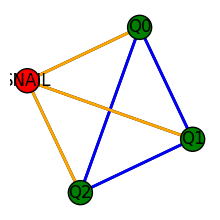

In [7]:
interaction_data = module.get_interaction_frequencies(qubit_freqs, snail_freq)
f_snail_sub = interaction_data["snail-sub"]["SNAIL"]

print(f"f_SNAIL/2 = {f_snail_sub:.4f} GHz\n")
print(f"{'gate':<14}{'pump (GHz)':>12}{'to f_S/2':>12}{'snail-sub cost':>16}{'fidelity':>12}")
infidelities = []
for edge in interaction_data["qubit-qubit"]:
    infidelity, _ = optimizer._compute_gate_infidelity(edge, interaction_data)
    infidelities.append(infidelity)
    pump = interaction_data["qubit-qubit"][edge]
    sub_cost = optimizer._unit_crosstalk(pump, "snail-sub", f_snail_sub)
    print(f"{str(edge):<14}{pump:>12.4f}{abs(pump - f_snail_sub) * 1e3:>9.1f} MHz"
          f"{sub_cost:>16.3e}{1 - infidelity:>12.6f}")

print(f"\nWorst-case gate fidelity: {1 - max(infidelities):.6f}")
print(f"Mean gate fidelity:       {1 - np.mean(infidelities):.6f}")

print(f"\nBare-mode clearance vs the QRAM band (guard = "
      f"{SYSTEM_PARAMS['min_bare_space_ghz'] * 1e3:.0f} MHz):")
for name, freq in list(interaction_data["qubit-resonance"].items()) + [
    ("SNAIL", snail_freq)
]:
    print(f"  {name:<5} {freq:.4f} GHz -> "
          f"{min(abs(freq - QRAM_FREQS)) * 1e3:8.1f} MHz from nearest QRAM state")

module.plot_graph(qubit_freqs, snail_freq)

## Which transmon couples to the QRAM?

One transmon is wired to the QRAM register directly. Converting between that transmon
and a QRAM state is a three-wave-mixing beamsplitter, so it is pumped at the
**difference frequency** $|f_{Q_k} - f_\mathrm{QRAM}|$ -- four conversion tones, one per
QRAM state, inheriting the register's 100 MHz spacing.

Score each candidate by the crowding its four conversion pumps would suffer from every
coherent spectator family, and take the best.

In [8]:
SPECTATOR_FAMILIES = ["qubit-qubit", "snail-qubit", "qubit-sub", "snail-sub"]


def qram_conversion_frequencies(qubit_freq, qram_freqs=None):
    """Beamsplitter pump frequencies |f_q - f_QRAM| for one transmon (GHz)."""
    if qram_freqs is None:
        qram_freqs = QRAM_FREQS
    return np.abs(qubit_freq - np.asarray(qram_freqs, dtype=float))


def conversion_crowding(optimizer, interaction_data, conversion_freqs):
    """Summed crosstalk the conversion pumps suffer from the module's spectators."""
    return sum(
        optimizer._unit_crosstalk(pump, family, spectator)
        for pump in conversion_freqs
        for family in SPECTATOR_FAMILIES
        for spectator in interaction_data[family].values()
    )


def mutual_crowding(optimizer, conversion_freqs):
    """Crowding the four conversion tones inflict on each other."""
    return sum(
        optimizer._unit_crosstalk(a, "qubit-qubit", b)
        for i, a in enumerate(conversion_freqs)
        for j, b in enumerate(conversion_freqs)
        if i != j
    )


print("Candidate QRAM-coupled transmons:")
scores = {}
for index, freq in enumerate(qubit_freqs):
    conv = qram_conversion_frequencies(freq)
    crowding = conversion_crowding(optimizer, interaction_data, conv)
    scores[index] = crowding
    print(f"  Q{index} at {freq:.4f} GHz: pumps {np.round(conv, 4)} GHz, "
          f"crowding {crowding:.4e}")

QRAM_QUBIT = min(scores, key=scores.get)
QRAM_QUBIT_LABEL = f"Q{QRAM_QUBIT}"
CONVERSION_FREQS = qram_conversion_frequencies(qubit_freqs[QRAM_QUBIT])

print(f"\n-> {QRAM_QUBIT_LABEL} at {qubit_freqs[QRAM_QUBIT]:.4f} GHz couples to the QRAM")
print(f"   conversion frequencies: {np.round(CONVERSION_FREQS, 4)} GHz")
print(f"   mutual crowding among the four tones: "
      f"{mutual_crowding(optimizer, CONVERSION_FREQS):.6e}")

Candidate QRAM-coupled transmons:
  Q0 at 3.5004 GHz: pumps [1.3496 1.4496 1.5496 1.6496] GHz, crowding 1.2078e+00
  Q1 at 3.3004 GHz: pumps [1.5496 1.6496 1.7496 1.8496] GHz, crowding 1.2130e+00
  Q2 at 3.8278 GHz: pumps [1.0222 1.1222 1.2222 1.3222] GHz, crowding 1.3152e+00

-> Q0 at 3.5004 GHz couples to the QRAM
   conversion frequencies: [1.3496 1.4496 1.5496 1.6496] GHz
   mutual crowding among the four tones: 1.200077e+00


## Frequency landscape

Everything on one axis: the module's bare modes and interaction frequencies, the four
QRAM states, and the four conversion tones that link the chosen transmon to them.

In [9]:
COLOR_MAP = {
    "qubit-qubit": "blue",
    "qubit-resonance": "green",
    "snail-qubit": "orange",
    "qubit-sub": "gray",
    "snail-sub": "magenta",
    "snail-resonance": "red",
}
LEGEND_LABELS = {
    "qubit-qubit": "Two-Qubit Gates",
    "qubit-resonance": "Qubit Modes",
    "snail-qubit": "SNAIL Qubit Difference",
    "qubit-sub": "Qubit Subharmonic",
    "snail-sub": "SNAIL Subharmonic",
    "snail-resonance": "SNAIL Mode",
}
QRAM_STATE_LABEL = "QRAM Modes"
BARE_MODE_TYPES = {"snail-resonance", "qubit-resonance"}
# The QRAM-coupled transmon gets its own colour so it is identifiable without a
# text callout. darkslateblue is the best-separated remaining hue: OKLab dE 15.3
# from green, the other solid bare-mode colour, which line style cannot disambiguate.
QRAM_QUBIT_COLOR = "darkslateblue"
CONVERSION_COLOR = "black"
FADED_ALPHA = 0.25
# Distinct y-levels (axes fraction) for each family's shift arrow, so arrows for
# different families don't stack on top of one another.
SHIFT_ARROW_Y = {"qubit-resonance": 0.85, "qubit-qubit": 0.5}
FIGURE_TITLE = "Frequency Allocation in 2 Qubit Module with QRAM"


def plot_interaction_frequencies_with_qram(
    module,
    qubit_frequencies,
    snail_frequency,
    qram_freqs=None,
    conversion_freqs=None,
    conversion_label=None,
    savepath=None,
    title=None,
    previous_qubit_frequencies=None,
    previous_conversion_freqs=None,
    exclude_families=None,
    shift_arrow_families=("qubit-resonance", "qubit-qubit"),
):
    """`QuantumModuleGraph.plot_interaction_frequencies`, plus the QRAM states and the
    conversion tones of the QRAM-coupled transmon.

    `previous_qubit_frequencies` (the pre-shift `qubit_frequencies`) and
    `previous_conversion_freqs` draw faded pre-shift positions with arrows to their new
    positions, for illustrating an AC Stark shift against the unshifted allocation.
    Shifted bare qubit modes and any two-qubit gate whose frequency moved get their own
    arrow (in `shift_arrow_families`); unaffected gates are left alone. The four
    conversion tones share a single grouped arrow instead, since a 100 MHz-spaced comb
    shifting by 50 MHz turns four overlapping arrowheads into noise.

    `exclude_families` skips the named `interaction_freqs` keys entirely -- useful for
    dropping families (e.g. `"qubit-sub"`) that aren't the point of a given figure and
    otherwise clutter the region around the QRAM conversion tones.
    """
    if qram_freqs is None:
        qram_freqs = qram_state_frequencies()
    if exclude_families is None:
        exclude_families = set()
    conversion_legend = (
        f"QRAM Conversion ({conversion_label})"
        if conversion_label
        else "QRAM Conversion"
    )
    conversion_legend = "QRAM Conversion"
    qram_qubit_legend = (
        f"QRAM Qubit ({conversion_label})" if conversion_label else "QRAM Qubit"
    )
    qram_qubit_legend = "QRAM Qubit"
    original_legend = "Original (pre-shift)"
    interaction_freqs = module.get_interaction_frequencies(
        qubit_frequencies, snail_frequency
    )
    previous_interaction_freqs = (
        module.get_interaction_frequencies(previous_qubit_frequencies, snail_frequency)
        if previous_qubit_frequencies is not None
        else None
    )
    all_freqs = (
        list(qubit_frequencies)
        + [snail_frequency]
        + list(qram_freqs)
        + (list(previous_qubit_frequencies) if previous_qubit_frequencies is not None else [])
    )

    with plt.style.context(["ieee", "use_mathtext", "science"]):
        fig, ax = plt.subplots(figsize=(3.5, 1))
        ax.set_xlim(0, max(all_freqs) * 1.05)
        ax.get_yaxis().set_visible(False)

        added_labels = set()
        for interaction_type, freqs in interaction_freqs.items():
            if not freqs or interaction_type in exclude_families:
                continue
            linestyle = (
                "-" if interaction_type in BARE_MODE_TYPES else (0, (2.1, 1.4))
            )
            for node, freq in freqs.items():
                # The QRAM-coupled transmon's own mode is drawn in its own colour.
                is_qram_qubit = (
                    interaction_type == "qubit-resonance"
                    and conversion_label is not None
                    and node == conversion_label
                )
                if is_qram_qubit:
                    color = QRAM_QUBIT_COLOR
                    legend_key = qram_qubit_legend
                else:
                    color = COLOR_MAP.get(interaction_type, "black")
                    legend_key = LEGEND_LABELS[interaction_type]
                label = legend_key if legend_key not in added_labels else ""
                ax.axvline(
                    freq,
                    color=color,
                    linestyle=linestyle,
                    linewidth=1.5,
                    alpha=0.8,
                    label=label,
                )
                added_labels.add(legend_key)

        for i, freq in enumerate(qram_freqs):
            ax.axvline(
                freq,
                color="purple",
                linestyle=(0, (1.0, 1.0)),  # dotted
                linewidth=1.0,
                alpha=0.9,
                label=QRAM_STATE_LABEL if i == 0 else "",
            )

        if conversion_freqs is not None:
            for i, freq in enumerate(conversion_freqs):
                ax.axvline(
                    freq,
                    color=CONVERSION_COLOR,
                    linestyle=(0, (3.0, 1.1, 0.7, 1.1)),  # dash-dot
                    linewidth=1.0,
                    alpha=0.9,
                    label=conversion_legend if i == 0 else "",
                )

        # Faded pre-shift positions plus arrows to their new (post-shift) positions.
        arrow_trans = ax.get_xaxis_transform()  # x in data coords, y in axes fraction
        first_original_label = original_legend
        if previous_interaction_freqs is not None:
            for family in shift_arrow_families:
                if family in exclude_families:
                    continue
                old_freqs = previous_interaction_freqs.get(family, {})
                new_freqs = interaction_freqs.get(family, {})
                for node, new_freq in new_freqs.items():
                    old_freq = old_freqs.get(node)
                    if old_freq is None or np.isclose(old_freq, new_freq, atol=1e-6):
                        continue  # unaffected by the shift -- nothing to draw
                    is_qram_qubit = (
                        family == "qubit-resonance"
                        and conversion_label is not None
                        and node == conversion_label
                    )
                    color = QRAM_QUBIT_COLOR if is_qram_qubit else COLOR_MAP[family]
                    ax.axvline(
                        old_freq,
                        color=color,
                        linestyle="-",
                        linewidth=1.2,
                        alpha=FADED_ALPHA,
                        label=first_original_label,
                    )
                    first_original_label = ""
                    ax.annotate(
                        "",
                        xy=(new_freq, SHIFT_ARROW_Y[family]),
                        xytext=(old_freq, SHIFT_ARROW_Y[family]),
                        xycoords=arrow_trans,
                        textcoords=arrow_trans,
                        arrowprops=dict(arrowstyle="-|>", color=color, lw=1.0),
                    )

        if previous_conversion_freqs is not None and conversion_freqs is not None:
            # Faint, thin, solid ticks mark each tone's old position -- solid rather
            # than dash-dot so they read as ghosts instead of a second competing
            # pattern layered on the new tones. One grouped arrow for the whole comb,
            # not one per tone: all four move by the same amount, and four arrowheads
            # crammed into a 100 MHz-wide window were unreadable.
            for old_freq in previous_conversion_freqs:
                ax.axvline(
                    old_freq,
                    color=CONVERSION_COLOR,
                    linestyle="-",
                    linewidth=0.8,
                    alpha=FADED_ALPHA,
                    label=first_original_label,
                )
                first_original_label = ""
            old_center = np.mean(previous_conversion_freqs)
            new_center = np.mean(conversion_freqs)
            ax.annotate(
                "",
                xy=(new_center, 0.15),
                xytext=(old_center, 0.15),
                xycoords=arrow_trans,
                textcoords=arrow_trans,
                arrowprops=dict(arrowstyle="-|>", color=CONVERSION_COLOR, lw=1.0),
            )

        ax.set_xlabel("Frequency (GHz)")
        ax.set_title(title if title is not None else FIGURE_TITLE, pad=10)

        legend_order = [
            "Qubit Modes",
            qram_qubit_legend,
            "SNAIL Mode",
            "Two-Qubit Gates",
            "Qubit Subharmonic",
            "SNAIL Qubit Difference",
            "SNAIL Subharmonic",
            QRAM_STATE_LABEL,
            conversion_legend,
            original_legend,
        ]
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(
            [by_label[lab] for lab in legend_order if lab in by_label],
            [lab for lab in legend_order if lab in by_label],
            loc="upper center",
            bbox_to_anchor=(0.5, -0.32),
            ncol=2,
            fontsize=8,
            columnspacing=0.8,
            handlelength=1.2,
        )
        if savepath is not None:
            fig.savefig(savepath, bbox_inches="tight")
    plt.show()
    return fig, ax

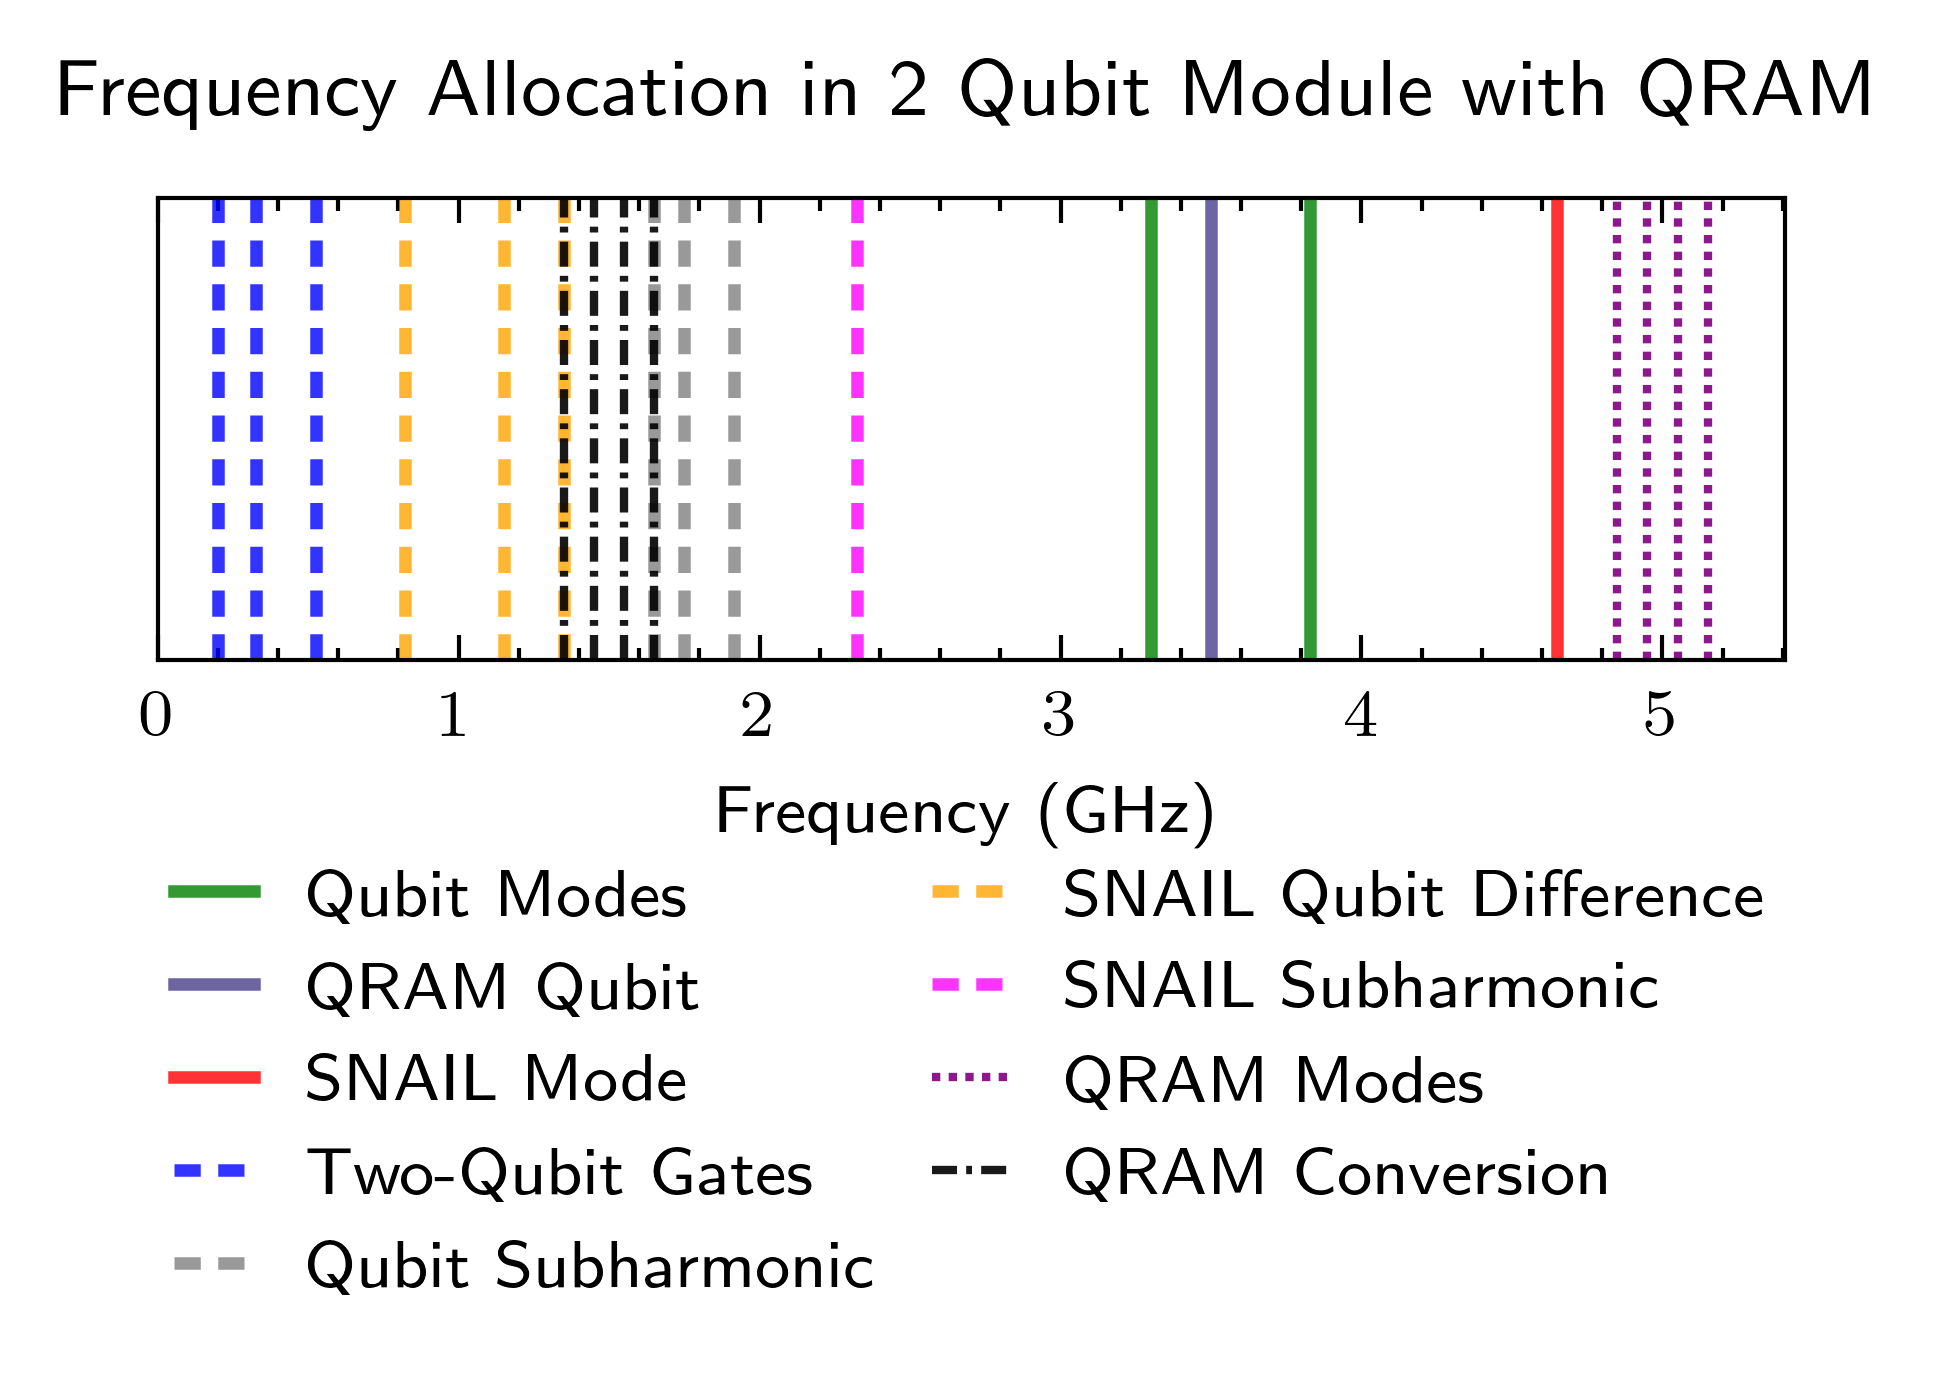

In [10]:
fig, ax = plot_interaction_frequencies_with_qram(
    module,
    qubit_freqs,
    snail_freq,
    qram_freqs=QRAM_FREQS,
    conversion_freqs=CONVERSION_FREQS,
    conversion_label=QRAM_QUBIT_LABEL,
    savepath=FIG_DIR / "qram_3q_snail_frequencies.pdf",
)

## AC Stark shift of the QRAM-coupled transmon

Driving the QRAM-coupled transmon (`QRAM_QUBIT_LABEL`) AC-Stark shifts its frequency
upward while leaving the QRAM register itself -- which lives on the memory/cavity side,
not the drive line -- untouched. Because the beamsplitter conversion pumps are set at
the *difference* frequency $|f_{Q_k} - f_\mathrm{QRAM}|$, a qubit shifted up by
$\delta$ means each conversion tone must be retuned down by $\delta$ to stay resonant.

Illustrated here with an indicative $\delta = 50$ MHz shift: the QRAM qubit moves right,
the QRAM states stay put, and the four conversion tones move left by the same amount.


Q0: 3.5004 GHz -> 3.5504 GHz (+50 MHz)
QRAM states:        unchanged, [4.85 4.95 5.05 5.15] GHz
Conversion tones:   [1.3496 1.4496 1.5496 1.6496] GHz -> [1.2996 1.3996 1.4996 1.5996] GHz (-50 MHz)


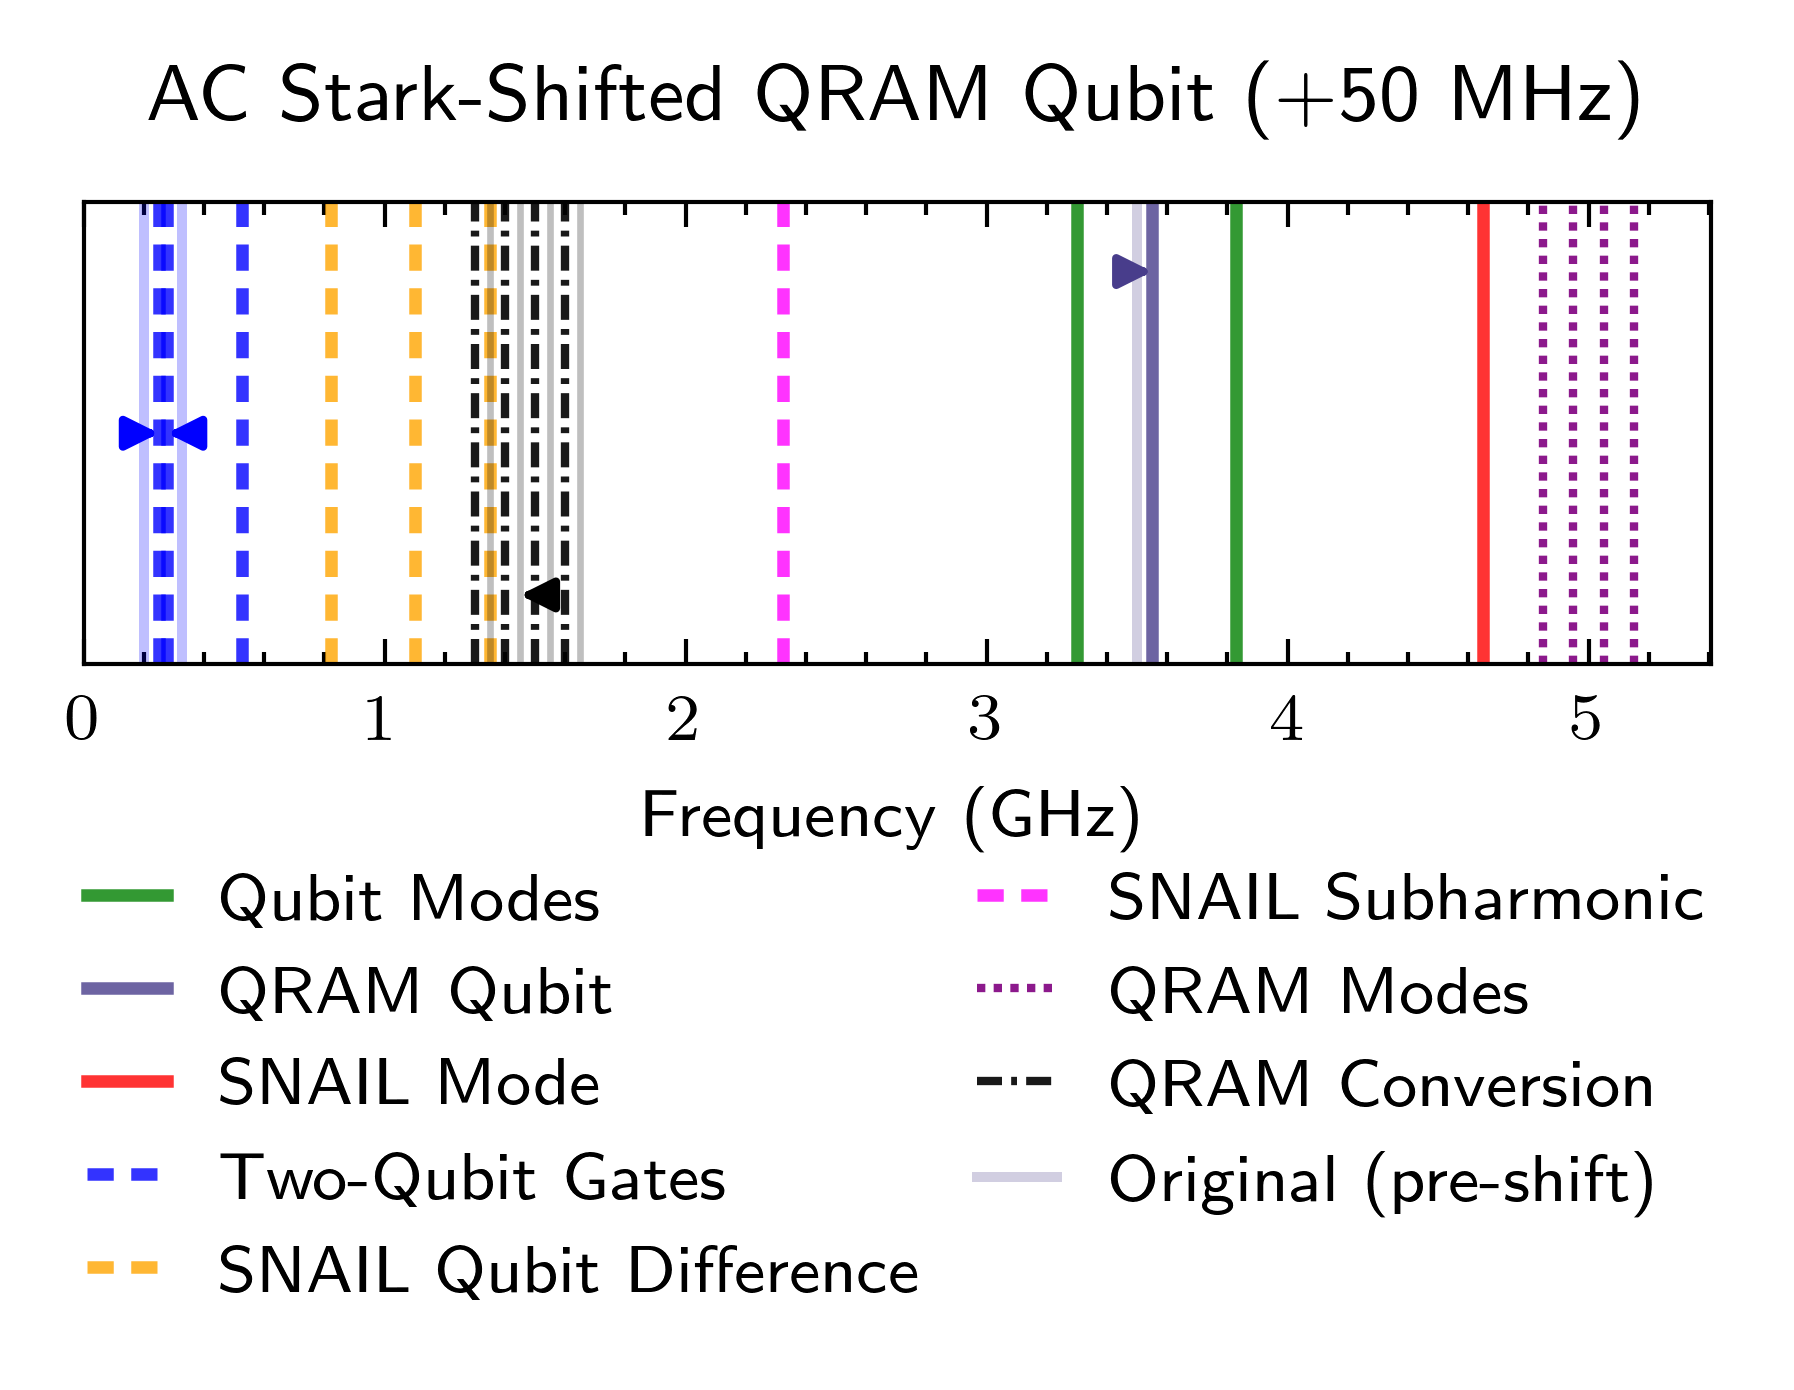

In [11]:
STARK_SHIFT_GHZ = 0.05  # ~50 MHz AC Stark shift on the QRAM-coupled transmon

stark_qubit_freqs = qubit_freqs.copy()
stark_qubit_freqs[QRAM_QUBIT] += STARK_SHIFT_GHZ
stark_conversion_freqs = CONVERSION_FREQS - STARK_SHIFT_GHZ

print(f"{QRAM_QUBIT_LABEL}: {qubit_freqs[QRAM_QUBIT]:.4f} GHz -> "
      f"{stark_qubit_freqs[QRAM_QUBIT]:.4f} GHz (+{STARK_SHIFT_GHZ * 1e3:.0f} MHz)")
print(f"QRAM states:        unchanged, {np.round(QRAM_FREQS, 4)} GHz")
print(f"Conversion tones:   {np.round(CONVERSION_FREQS, 4)} GHz -> "
      f"{np.round(stark_conversion_freqs, 4)} GHz (-{STARK_SHIFT_GHZ * 1e3:.0f} MHz)")

fig, ax = plot_interaction_frequencies_with_qram(
    module,
    stark_qubit_freqs,
    snail_freq,
    qram_freqs=QRAM_FREQS,
    conversion_freqs=stark_conversion_freqs,
    conversion_label=QRAM_QUBIT_LABEL,
    title="AC Stark-Shifted QRAM Qubit (+50 MHz)",
    previous_qubit_frequencies=qubit_freqs,
    previous_conversion_freqs=CONVERSION_FREQS,
    exclude_families={"qubit-sub"},  # crowds the conversion-tone band; not the point here
    savepath=FIG_DIR / "qram_3q_snail_frequencies_stark_shifted.pdf",
)

### Remaining caveats

- **`snail_sub_participation` defaults to $\lambda_q$, not 1.** See the discussion
  above: the literal participation counting gives a non-perturbative, non-monotonic
  curve that `decay_fit` cannot fit. The default keeps the term well-behaved, but it
  *understates* the SNAIL's participation by $1/\lambda_q = 12.5$. Treat the absolute
  subharmonic cost as a lower bound.
- **`use_lifetime=True` now double-counts the subharmonic**, once coherently and once as
  the pump-power speed limit. Other notebooks that pass `use_lifetime=True` (e.g.
  `07_numerics`) will report different numbers than before this term was added.
- **The conversion tones are scored, not optimized.** They are not terms in
  `compute_total_infidelity`, so nothing makes the allocation leave room for them.
- **The four tones are 100 MHz apart by construction**, inheriting the register spacing,
  which is inside `alpha = 120 MHz` -- so they crowd each other more than the module
  crowds them. No choice of transmon fixes that; only a wider QRAM spacing or a
  pump-selective scheme does.
- `qutrit_detuning_fit.py` / `qutrit_allocation_optimizer.py` were left untouched; they
  have no `snail-sub` term.